In [148]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [149]:

df=pd.read_csv(r"C:\Users\Dev\OneDrive\Desktop\data\loan_data_2007_2014.csv")

C:\Users\Dev\AppData\Local\Temp\ipykernel_43124\4010796795.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r"C:\Users\Dev\OneDrive\Desktop\data\loan_data_2007_2014.csv")


In [150]:
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

In [152]:
# From analyzing df.info we found that the following columns are irrelevant and they will not be beneficial for further analysis That's why they are going to be deleted
irr_col = df.iloc[:,[0, 54, 55, 56, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70,72, 73, 74]].columns

In [153]:
df=df.drop(columns=irr_col,axis=1)


In [154]:
df.shape

(466285, 57)

In [155]:
print(df[df.notnull()].head(8).to_string())

# Relation - total_pymnt = total_rec_prncp + total_rec_int + total_rec_late_fee + recoveries

        id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  installment grade sub_grade                  emp_title emp_length home_ownership  annual_inc verification_status issue_d  loan_status pymnt_plan                                                                   url                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            desc             purpose                                  title zip_code addr_state    dti  delinq_2yrs earliest

# Lending Club Loan Dataset - Column Descriptions

### id
Unique identifier for each loan application.

### member_id
Unique identifier assigned to each borrower/member.

### loan_amnt
Amount of money requested by the borrower.

### funded_amnt
Total amount funded by investors(The amount approved by the bank to the customer).
- May be equal to or less than the requested loan amount.
- Shows how much money was actually approved and funded.

### funded_amnt_inv
Amount funded specifically by investors of Bank.
- Represents investor participation in the loan.

### term
Length of the loan repayment period.

### int_rate
Interest rate charged on the loan.

### installment
Fixed monthly payment amount.

### grade
Overall credit grade assigned by Lending Club.
- Grades range from A (lowest risk) to G (highest risk).

### sub_grade
More detailed risk category within each grade.
- Provides finer classification of borrower risk.
- Example: B1 is generally better than B5.
### emp_title
Borrower's job title.

### emp_length
Length of employment.

### home_ownership
Borrower's housing status.

### annual_inc
Borrower's annual income.

### verification_status
Income verification status.
- Shows whether income was verified by Lending Club.

### issue_d
Date when the loan was issued.

### pymnt_plan
Indicates whether a payment plan exists.
- Usually "n" (No).
- Rarely varies in the dataset.
Instead of immediately declaring the loan as default, the lender may offer a modified repayment schedule, such as:

    * Reduced monthly payments
    * Temporary payment pause
    * Extended loan term
- Other repayment arrangements
### url
Web link to loan details.

### desc
Borrower's description of loan purpose.

### purpose
Main reason for taking the loan.
- Examples: credit_card, car, home_improvement.

### title
Short title provided by borrower.

### zip_code
Borrower's ZIP code.

### addr_state
State where borrower resides.

### dti
Debt-to-Income Ratio.
- Measures debt burden relative to income.
- portion of income involve in past debts
- It shows the portion of person's income involved in repaying past debts

### delinq_2yrs
Number of delinquencies in the last 2 years.
- Indicates past repayment issues.
- Higher values suggest greater credit risk.
- Delinquency
A delinquency occurs when a borrower fails to make a required loan payment by its due date.

### earliest_cr_line
Date of borrower's first credit account.
- Reflects credit history length.
- Older credit histories are generally preferred.
- A credit account is any account through which a person borrows money or uses credit and is expected to repay it later.

### inq_last_6mths
Credit inquiries in the last 6 months.
- Shows recent credit-seeking activity.
- Too many inquiries may indicate risk.

### mths_since_last_delinq
Months since last delinquency.
- Measures time since a missed payment event.
- Larger values generally indicate better behavior.

### mths_since_last_record
Months since last public record.
- Refers to negative public records.
- Missing values often mean no record exists.
- A public record is a serious financial issue reported in public databases, such as:
- Bankruptcy
- Tax lien
- Court judgment

### open_acc
Number of open credit accounts.
- Reflects active credit usage.
- Moderate values are generally considered healthy.

### pub_rec
Number of derogatory public records.
- Includes bankruptcies, judgments, etc.
- Higher values indicate increased risk.

### revol_bal
Outstanding revolving credit balance.
- Amount currently owed/used on revolving accounts.
- Often associated with credit card debt.
- Revolving accounts are credit accounts where you can borrow, repay, and borrow again up to a credit limit.

### revol_util
Revolving credit utilization rate.
- Percentage of available credit limit that has been used.
- High utilization may signal financial stress.


### total_acc
Total number of credit accounts.
- Measures overall credit experience.
- Higher values may indicate a longer credit history.

### initial_list_status
Initial listing status of the loan.
- Indicates how the loan was offered by investors to customer(borrower).
- Usually has categories such as 'f'(fractional) or 'w'(whole).
- f - The loan could be funded by multiple investors
- w - The loan was available to be funded by a single institutional or large investor.

### out_prncp
Remaining principal balance.
- Amount still owed on the loan.
- Zero usually indicates the loan is paid off.

### out_prncp_inv
Remaining investor-funded principal.
- Outstanding balance attributable to investors.
- Useful for investor performance analysis.

### total_pymnt
Total amount paid by borrower.
- Includes principal, interest, and fees.
- Measures overall repayment.

### total_pymnt_inv
Total payment received by investors.
- Investor portion of repayments.
- Used for investment return analysis.

### total_rec_prncp
Total principal received.
- Amount of original loan returned.
- Indicates progress toward loan payoff.

### total_rec_int
Total interest received.
- Interest earned from the loan.
- Important for lender profitability.

### total_rec_late_fee
Total late fees collected/recieved.
- Fees charged due to late payments.
- Higher values may indicate repayment issues.

### recoveries
Recovered amount after default.
- Money recovered from charged-off loans.
- Helps reduce lender losses.

### collection_recovery_fee
Fees associated with recovery efforts.
- Cost of collecting defaulted loans.
- Related to recovery activities.
- This is bank's expense to collect the loan 

### last_pymnt_d
Date of most recent payment.
- Shows latest borrower activity.
- Useful for repayment tracking.

### last_pymnt_amnt
Amount of last payment made.
- Reflects the most recent installment.
- Can indicate payment behavior.

### next_pymnt_d
Scheduled next payment date.
- Usually available for active loans.
- Missing for completed loans.

### last_credit_pull_d
Date of last credit report pull.
- Indicates most recent credit check of borrower.
- Useful for account monitoring.

### collections_12_mths_ex_med
Collections in last 12 months excluding medical.
- Measures recent collection activity.
- Higher values may indicate risk.

### mths_since_last_major_derog
Months since last major derogatory event.
- Includes serious credit issues.
- Larger values generally indicate better credit history.

### policy_code
Internal Lending Club policy code.
- Mostly constant across records.
- Rarely used for analysis.

### application_type
Type of loan application.
- Examples: INDIVIDUAL or JOINT.
- Useful for borrower segmentation.

### acc_now_delinq
Number of accounts currently delinquent.
- Measures current repayment problems.
- Higher values suggest elevated risk.

### tot_coll_amt
Total collection amount owed.
- Amount in collections.
- amount of debt that has been sent to a collection agency because the borrower failed to make payments on time
- Higher values indicate financial difficulty.

### tot_cur_bal
Total balance across all accounts.
- Measures total outstanding debt.
- Useful for assessing overall leverage.

### all_util
Overall credit utilization rate.
- Percentage of total available credit used.
- High values may indicate financial strain.

### total_rev_hi_lim
Total revolving credit limit.
- Maximum revolving credit available.
- Helps assess credit capacity.

In [156]:
df[["loan_status"]].value_counts()

loan_status                                        
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

### loan_status(Target var)
Current status of the loan, indicating whether the borrower is repaying the loan as agreed or has encountered repayment difficulties.

**Categories:**

- **Current**: The borrower is making payments on time and the loan is still active.
- **Fully Paid**: The loan has been completely repaid.
- **Charged Off**: The loan is considered a loss because the borrower failed to repay.
- **Late (31–120 days)**: The payment is overdue by 31 to 120 days.
- **Late (16–30 days)**: The payment is overdue by 16 to 30 days.
- **In Grace Period**: The payment is overdue but still within the allowed grace period.
- **Default**: The borrower has failed to meet repayment obligations.
- **Does not meet the credit policy. Status: Fully Paid**: The loan did not meet Lending Club's credit policy but was repaid successfully.
- **Does not meet the credit policy. Status: Charged Off**: The loan did not meet Lending Club's credit policy and was eventually charged off.

**Interpretation:**
- `Current` and `Fully Paid` indicate healthy loan performance.
- `Charged Off`, `Default`, and `Late` statuses indicate higher credit risk.

In [157]:
df[df['loan_status']== 'Current'].shape

(224226, 57)

In [158]:
# On observing all the columns we found that the URL column is just a link of the customers account on Lending club, So we are deleting it 
df = df.drop('url',axis=1) 

In [159]:
print(df.head().to_string())

        id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  installment grade sub_grade                 emp_title emp_length home_ownership  annual_inc verification_status issue_d  loan_status pymnt_plan                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            desc         purpose                 title zip_code addr_state    dti  delinq_2yrs earliest_cr_line  inq_last_6mths  mths_since_last_delinq  mths_since_last_record  open_acc  pub_rec 

## Initial data cleaning

In [160]:
# Checking which features have null values
total_entries = df.iloc[:,0].shape[0]


col_with_null_values = []

for i in range(len(df.columns)):
    if df.iloc[:,i].notna().sum() < total_entries:                  # checking number of no null entries in each column
        col_with_null_values.append(df.columns[i])

In [161]:
# List of columns with null values
col_with_null_values 

['emp_title',
 'emp_length',
 'annual_inc',
 'desc',
 'title',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_util',
 'total_acc',
 'last_pymnt_d',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'total_rev_hi_lim']

In [162]:
# This is a function that will calculate the total null values and the proportion to whole figure of null values
def missing_values(colm_name, rstate = 45):

    print("____________________________________________________")
    print(f"\tAnalysing column - {colm_name}")
    print("____________________________________________________\n")

    print("5 sample values----\n")
    print(df.loc[:,colm_name].sample(5,random_state=rstate))    

    # Calcluation of null values
    miss_val = df.loc[:,colm_name].isna().sum()

    total_entries =  df.shape[0]
    return f'The column {colm_name} has {miss_val} missing values, it is {miss_val*100/total_entries:.5} % of total values'


# Col - 1

In [163]:
m1 =  col_with_null_values[0]                    # missing col 1 - m1
missing_values(m1)

____________________________________________________
	Analysing column - emp_title
____________________________________________________

5 sample values----

47140     Relief Control Operator B
307584         Sales Representative
209316                    Odebrecht
116227              MassDevelopment
272299              Yard supervisor
Name: emp_title, dtype: object


'The column emp_title has 27588 missing values, it is 5.9166 % of total values'

In [164]:
df[[m1]].nunique()    # emp_title    205475
# Since this column has 1.49% of missing values and the employee title has 2,05,000 categories(so we cant categroize them randomly),hence we are imputing it with "unknown" 
df[[m1]] = df[[m1]].fillna('UNKNOWN')

# Col - 2

In [165]:
m2 =  col_with_null_values[1]                    # missing col 1 - m1
missing_values(m2)

____________________________________________________
	Analysing column - emp_length
____________________________________________________

5 sample values----

47140     10+ years
307584      3 years
209316      2 years
116227      9 years
272299    10+ years
Name: emp_length, dtype: object


'The column emp_length has 21008 missing values, it is 4.5054 % of total values'

In [166]:
print(df [df[['emp_length']].isna().any(axis=1)].sample(40).to_string())


              id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  installment grade sub_grade emp_title emp_length home_ownership  annual_inc verification_status issue_d  loan_status pymnt_plan                                                                                                                                                                                                                                                                        desc             purpose                       title zip_code addr_state    dti  delinq_2yrs earliest_cr_line  inq_last_6mths  mths_since_last_delinq  mths_since_last_record  open_acc  pub_rec  revol_bal  revol_util  total_acc initial_list_status  out_prncp  out_prncp_inv   total_pymnt  total_pymnt_inv  total_rec_prncp  total_rec_int  total_rec_late_fee  recoveries  collection_recovery_fee last_pymnt_d  last_pymnt_amnt next_pymnt_d last_credit_pull_d  collections_12_mths_ex_med  mths_since_last_major_derog  poli

In [167]:
# Creating a duplicate data frame and filling the employee length with any to see which employee title has none employ length
df2  = df[['emp_title','emp_length']][df[['emp_length']].isna().any(axis=1)].copy()
df2['emp_length'] = df2['emp_length'].fillna('AA')

print(df2.groupby('emp_title')['emp_length'].count().to_string())  
# From the group by we have found that Around 20882  out of 21008 are Are the missing employee length of those who has not given their name in employee title
# We are imputing it with 'Unknown'

del df2

emp_title
AEM Corporation                                1
AL Medicaid Agency                             1
Adjunct Instructor                             1
Administrative Assistant                       1
Aegis Communications Group                     1
Albany Door Systems                            1
American Fire Equipment                        1
Arizona's Best Choice Pest                     1
Army Officer                                   1
Assistant Principal                            1
Asso. Illinois Middle Schools                  1
Astro-tec Manufacturing Inc                    1
Attorney-at-Law                                1
Belk                                           1
Binghamton University                          1
Business Analyst                               1
Business Assistant                             1
CAL FIRE                                       1
CBS Corporation                                1
CERTIFIED MARINE                               1
California

In [168]:
df.loc[(df['emp_length'].isna()) & (df['emp_title'] == 'UNKNOWN'),'emp_length'] = "UNKNOWN"

In [169]:
missing_values(m2)

____________________________________________________
	Analysing column - emp_length
____________________________________________________

5 sample values----

47140     10+ years
307584      3 years
209316      2 years
116227      9 years
272299    10+ years
Name: emp_length, dtype: object


'The column emp_length has 186 missing values, it is 0.03989 % of total values'

In [170]:
df[[m2]].value_counts()

# Plotting a bar plot for the employee length and their frequency
freq = df[[m2]].value_counts().values
x_axis = []

for i in range(len(freq)):
    category = df[[m2]].value_counts().index[i][0]
    x_axis.append(category)

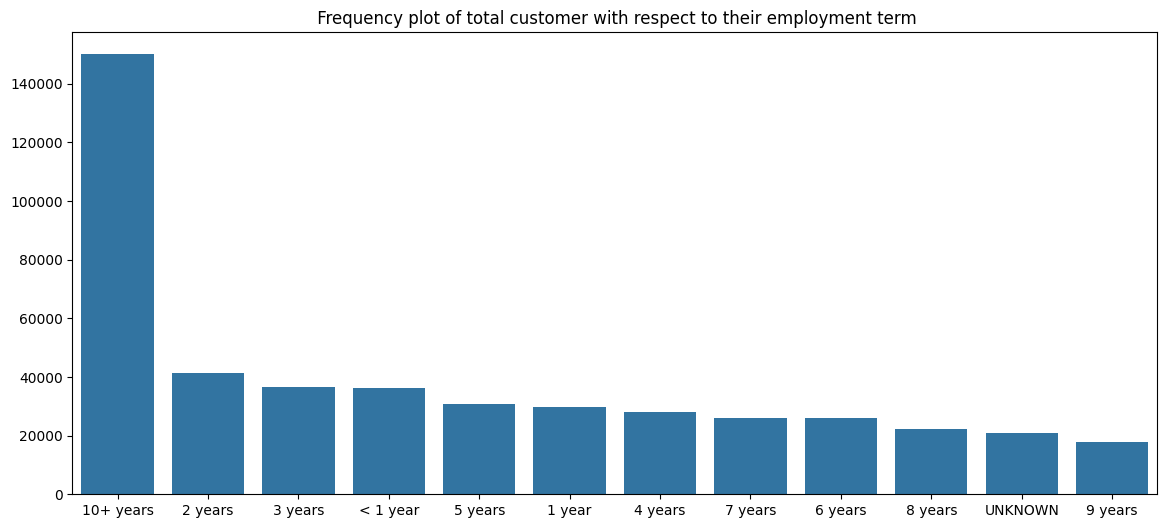

In [171]:

plt.figure(figsize=(14,6))
sns.barplot(x= x_axis , y = freq)
plt.title(" Frequency plot of total customer with respect to their employment term")
plt.show()

In [172]:
# On observing the hist we can say that a majority of the custom having employment year more than 10 and all of the others have significantly less employment years So if you drop the 180 null values of different categories they will not be an effect
row_index = df[ df[m2].isna() ].index    
df = df.drop(index = row_index , axis = 0)

In [173]:
df[[m2]].value_counts()

# Plotting a bar plot for the employee length and their frequency
freq = df[[m2]].value_counts().values
x_axis = []

for i in range(len(freq)):
    category = df[[m2]].value_counts().index[i][0]
    x_axis.append(category)

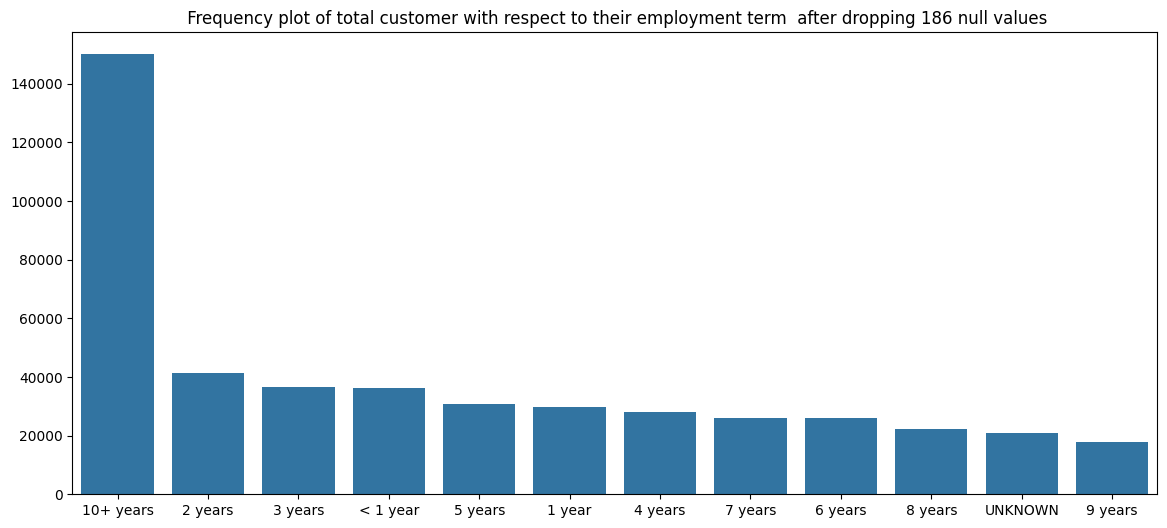

In [174]:

plt.figure(figsize=(14,6))
sns.barplot(x= x_axis , y = freq)
plt.title(" Frequency plot of total customer with respect to their employment term  after dropping 186 null values")
plt.show()

# Col - 3

In [175]:
m3 =  col_with_null_values[2]                    # missing col 1 - m1
missing_values(m3)

____________________________________________________
	Analysing column - annual_inc
____________________________________________________

5 sample values----

303456    70000.0
379786    40000.0
54363     90000.0
317647    50000.0
424741    65000.0
Name: annual_inc, dtype: float64


'The column annual_inc has 4 missing values, it is 0.00085819 % of total values'

In [176]:
print(df.loc[df[m3].isnull(),:].head().to_string())


          id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  installment grade sub_grade emp_title emp_length home_ownership  annual_inc verification_status issue_d                                         loan_status pymnt_plan                                                                                                                        desc purpose                                 title zip_code addr_state  dti  delinq_2yrs earliest_cr_line  inq_last_6mths  mths_since_last_delinq  mths_since_last_record  open_acc  pub_rec  revol_bal  revol_util  total_acc initial_list_status  out_prncp  out_prncp_inv  total_pymnt  total_pymnt_inv  total_rec_prncp  total_rec_int  total_rec_late_fee  recoveries  collection_recovery_fee last_pymnt_d  last_pymnt_amnt next_pymnt_d last_credit_pull_d  collections_12_mths_ex_med  mths_since_last_major_derog  policy_code application_type  acc_now_delinq  tot_coll_amt  tot_cur_bal  total_rev_hi_lim
42449  79967      79912     

count    4.660950e+05
mean     7.328321e+04
std      5.496444e+04
min      1.896000e+03
25%      4.500000e+04
50%      6.300000e+04
75%      8.900000e+04
max      7.500000e+06
Name: annual_inc, dtype: float64


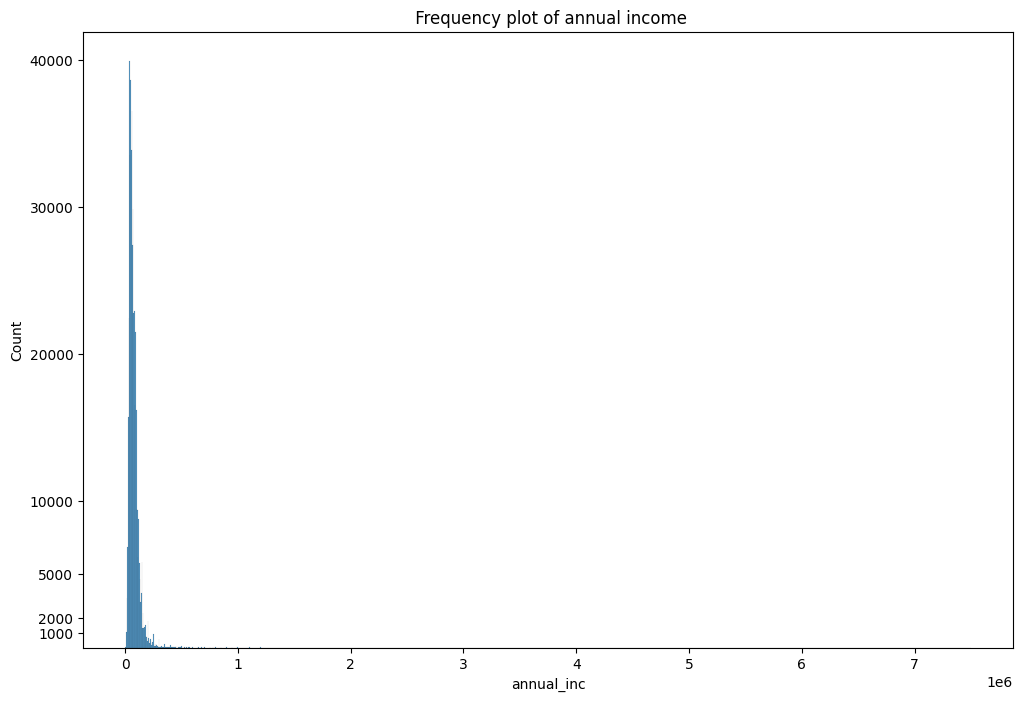

In [177]:

print(df['annual_inc'][df['annual_inc'].notna()].describe())


# Best plot of annual income
plt.figure(figsize= (12,8))
sns.histplot( df['annual_inc'][df['annual_inc'].notna()] )
plt.yticks([1000,2000,5000,10000,20000,30000,40000])
plt.title(' Frequency plot of annual income')

plt.show()


In [178]:
print('''From the hist plot we can see the majority of the population are having income lesser than one 1 lakh
and also that the plot positively skewed Means that as the annual income increases the total number of
customers with that salary decreases''')

From the hist plot we can see the majority of the population are having income lesser than one 1 lakh
and also that the plot positively skewed Means that as the annual income increases the total number of
customers with that salary decreases


In [179]:
# Some Observatios
annual_income = pd.DataFrame()


percent_cust_less = []
for salary in range(50000,1000001,100000):
    percent_cust_less.append( (len(df['annual_inc'][df['annual_inc'] <= salary]) * 100)/len(df) )


percent_cust_greater = []
for salary in range(50000,1000001,100000):
    percent_cust_greater.append( (len(df['annual_inc'][df['annual_inc'] > salary]) * 100)/len(df) )




annual_income ['<=salary'] = range(50000,1000001,100000)

annual_income ['proportion_of_customers <= salary'] = percent_cust_less
annual_income ['number_of_customers <= salary'] = np.array(percent_cust_less) * len(df)/100

annual_income ['proportion_of_customers > salary'] = percent_cust_greater
annual_income ['number_of_customers > salary'] = np.array(percent_cust_greater) * len(df)/100


print(""" 
From this table we can directly see that around 95% of the whole population of customers having annual income less or equal to 1.5 lakh
Only a few number of customers having of more than 9.5 lakh""")
annual_income

 
From this table we can directly see that around 95% of the whole population of customers having annual income less or equal to 1.5 lakh
Only a few number of customers having of more than 9.5 lakh


,<=salary,proportion_of_customers <= salary,number_of_customers <= salary,proportion_of_customers > salary,number_of_customers > salary
0,50000,33.816421,157618.0,66.182721,308477.0
1,150000,95.578193,445489.0,4.420949,20606.0
2,250000,99.214330,462437.0,0.784812,3658.0
3,350000,99.717871,464784.0,0.281271,1311.0
4,450000,99.860116,465447.0,0.139026,648.0
5,550000,99.921261,465732.0,0.077880,363.0
6,650000,99.949152,465862.0,0.049989,233.0
7,750000,99.964385,465933.0,0.034757,162.0
8,850000,99.974469,465980.0,0.024673,115.0
9,950000,99.982193,466016.0,0.016949,79.0


In [180]:
median_annual_salary = df['annual_inc'].median()
(len(df['annual_inc'][df['annual_inc'] <= df['annual_inc'].mean()]) * 100)/len(df)

61.99627117844063

In [181]:
df['annual_inc'].mean()
df['annual_inc'].median()

# Now since these are only 4 Missing values If either we feel me or Medium there will be no effect on data distribution

63000.0

In [182]:
df[m3] = df[m3].fillna(df['annual_inc'].median())

# Col - 4

In [183]:
m4 =  col_with_null_values[3]                    # missing col 1 - m1
missing_values(m4)

____________________________________________________
	Analysing column - desc
____________________________________________________

5 sample values----

303456    NaN
379786    NaN
54363     NaN
317647    NaN
424741    NaN
Name: desc, dtype: object


'The column desc has 340179 missing values, it is 72.984 % of total values'

In [184]:
df = df.drop('desc', axis = 1)

- The desc column was dropped because it contains unstructured borrower-written text with approximately 18.9% missing values. Since the project focuses on structured machine learning models and does not involve natural language processing, the feature was excluded from exploratory data analysis and model development. This also reduces preprocessing complexity without losing key structured information.

# Col - 5

In [185]:
m5 =  col_with_null_values[4]                    # missing col 1 - m1
missing_values(m5)

____________________________________________________
	Analysing column - title
____________________________________________________

5 sample values----

303456      Home improvement
379786    Debt consolidation
54363                 Loan 2
317647    Debt consolidation
424741    Debt consolidation
Name: title, dtype: object


'The column title has 21 missing values, it is 0.0045055 % of total values'

### Imputing `title`
- Categorical loan purpose, only 21 missing (~0.001%).
- Negligible count — fill with the most frequent category (mode).

In [186]:
df[[m5]] = df[[m5]].fillna(df[m5].mode()[0])
print(df[m5].isna().sum())

0


# Col - 6

In [187]:
m6 =  col_with_null_values[5]                    # missing col 1 - m1
missing_values(m6)

____________________________________________________
	Analysing column - delinq_2yrs
____________________________________________________

5 sample values----

303456    1.0
379786    1.0
54363     0.0
317647    0.0
424741    1.0
Name: delinq_2yrs, dtype: float64


'The column delinq_2yrs has 29 missing values, it is 0.0062219 % of total values'

### Imputing `delinq_2yrs`
- Numeric count, only 29 missing (~0.002%).
- Right-skewed (mostly 0s) — median is safer than mean.

In [188]:
df[[m6]] = df[[m6]].fillna(df[m6].median())
print(df[m6].isna().sum())

0


# Col - 7

In [189]:
m7 =  col_with_null_values[6]                    # missing col 1 - m1
missing_values(m7)

____________________________________________________
	Analysing column - earliest_cr_line
____________________________________________________

5 sample values----

303456    Apr-00
379786    Nov-06
54363     Nov-00
317647    Nov-03
424741    Oct-01
Name: earliest_cr_line, dtype: object


'The column earliest_cr_line has 29 missing values, it is 0.0062219 % of total values'

In [190]:
# earliest_cr_line (the date when the borrower first opened any credit account,
#  such as a credit card, personal loan, home loan, etc.)

# Checking whether the customer with no earliest credit line has dates in issue_d

df.loc[df["earliest_cr_line"].isna(), ["issue_d", "earliest_cr_line"]]

,issue_d,earliest_cr_line
42449,Aug-07,NaN
42450,Aug-07,NaN
42459,Aug-07,NaN
42472,Aug-07,NaN
42480,Jul-07,NaN
42483,Jul-07,NaN
42494,Jul-07,NaN
42509,Jul-07,NaN
42514,Jun-07,NaN
42515,Jun-07,NaN


In [191]:
mis_idx = df[m7][df[m7].isna()].index
df.loc[mis_idx,m7] = df.loc[mis_idx,'issue_d']

- The earliest_cr_line feature contained only 21 missing values. These were imputed using the corresponding issue_d values under the assumption that, for borrowers with no recorded prior credit history, the current loan represents their earliest known credit account. This approach preserves the observations while maintaining a logically consistent timelin

# Col - 8

In [192]:
m8 =  col_with_null_values[7]                    # missing col 1 - m1
missing_values(m8)
print('\n\nNumber of credit inquiries made in the last 6 months.')

____________________________________________________
	Analysing column - inq_last_6mths
____________________________________________________

5 sample values----

303456    3.0
379786    0.0
54363     0.0
317647    0.0
424741    0.0
Name: inq_last_6mths, dtype: float64


Number of credit inquiries made in the last 6 months.


In [193]:
df[m8].value_counts()

inq_last_6mths
0.0     241415
1.0     130094
2.0      57790
3.0      25120
4.0       7238
5.0       2766
6.0       1185
7.0        195
8.0        122
9.0         50
10.0        24
11.0        15
12.0        15
15.0         9
13.0         6
14.0         6
18.0         4
16.0         3
17.0         2
24.0         2
19.0         2
32.0         1
33.0         1
31.0         1
28.0         1
25.0         1
27.0         1
20.0         1
Name: count, dtype: int64

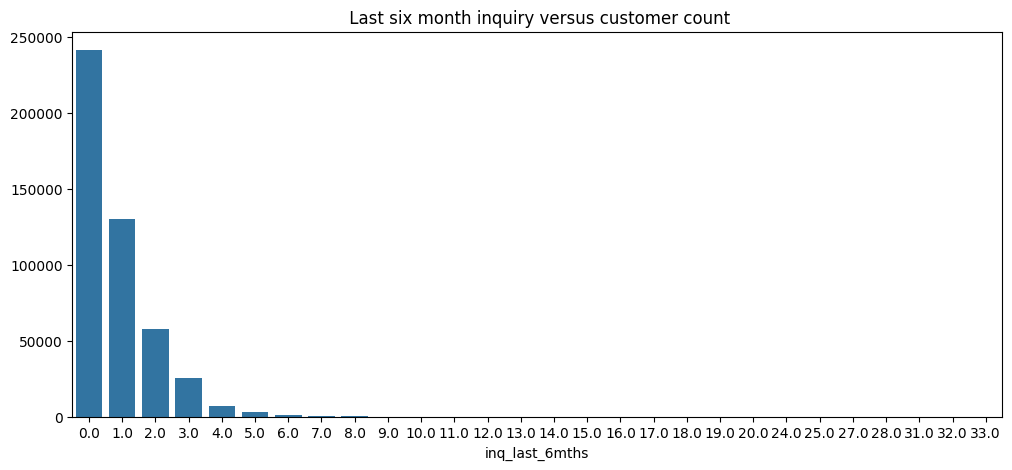

In [194]:
plt.figure(figsize=(12,5))
sns.barplot(x= df[m8].value_counts().index , y= df[m8].value_counts().values)
plt.title(' Last six month inquiry versus customer count')
plt.show()

### Imputing `inq_last_6mths`
- Numeric count, only 29 missing (~0.002%).
- Right-skewed — median preferred over mean.

In [195]:
df[[m8]] = df[[m8]].fillna(df[m8].median())
print(df[m8].isna().sum())

0


# Col - 9

In [196]:
m9 =  col_with_null_values[8]                    # missing col 1 - m1
missing_values(m9)

____________________________________________________
	Analysing column - mths_since_last_delinq
____________________________________________________

5 sample values----

303456    20.0
379786    23.0
54363      NaN
317647    48.0
424741    21.0
Name: mths_since_last_delinq, dtype: float64


'The column mths_since_last_delinq has 250223 missing values, it is 53.685 % of total values'

### Imputing `mths_since_last_delinq`


In [197]:
# it means : Months since the borrower's last delinquency.
# A delinquency means the borrower was late on a credit payment (e.g., credit card, loan, etc.)

print("""Around 53 % of the total customer
 has no delinquency month
means maybe there is no late payment on that customer so we are
imputing it with zero instead of a mean median mode""")

df[[m9]] = df[[m9]].fillna(0)
print(df[m9].isna().sum())

Around 53 % of the total customer
 has no delinquency month
means maybe there is no late payment on that customer so we are
imputing it with zero instead of a mean median mode
0


In [198]:
df[[m9]].value_counts()

mths_since_last_delinq
0.0                       251446
9.0                         4358
8.0                         4272
13.0                        4259
12.0                        4190
                           ...  
119.0                          1
118.0                          1
111.0                          1
109.0                          1
188.0                          1
Name: count, Length: 145, dtype: int64

# Col - 10

In [199]:
m10 =  col_with_null_values[9]                    # missing col 1 - m1
missing_values(m10)

____________________________________________________
	Analysing column - mths_since_last_record
____________________________________________________

5 sample values----

303456      NaN
379786      NaN
54363       NaN
317647     81.0
424741    116.0
Name: mths_since_last_record, dtype: float64


'The column mths_since_last_record has 403490 missing values, it is 86.567 % of total values'

In [200]:
print("""This feature means:Months since the borrower's last public record.

A public record is usually a serious negative credit event, such as:

Bankruptcy
Tax lien
Civil judgment

Other public legal/financial records""")

This feature means:Months since the borrower's last public record.

A public record is usually a serious negative credit event, such as:

Bankruptcy
Tax lien
Civil judgment

Other public legal/financial records


In [201]:
# Imputing with 0 - means no public record has ever been reported
df[[m10]] = df[[m10]].fillna(0)
missing_values(m10)

____________________________________________________
	Analysing column - mths_since_last_record
____________________________________________________

5 sample values----

303456      0.0
379786      0.0
54363       0.0
317647     81.0
424741    116.0
Name: mths_since_last_record, dtype: float64


'The column mths_since_last_record has 0 missing values, it is 0.0 % of total values'

# Col - 11

In [202]:
m11 =  col_with_null_values[10]                    # missing col 1 - m1
missing_values(m11)

____________________________________________________
	Analysing column - open_acc
____________________________________________________

5 sample values----

303456     8.0
379786    16.0
54363     15.0
317647    10.0
424741    12.0
Name: open_acc, dtype: float64


'The column open_acc has 29 missing values, it is 0.0062219 % of total values'

In [203]:
print("It simply means no of loan accounts, like-")
print("a customer might have multiple loan accounts like - credit cards, personal loans , home loan etc")

It simply means no of loan accounts, like-
a customer might have multiple loan accounts like - credit cards, personal loans , home loan etc


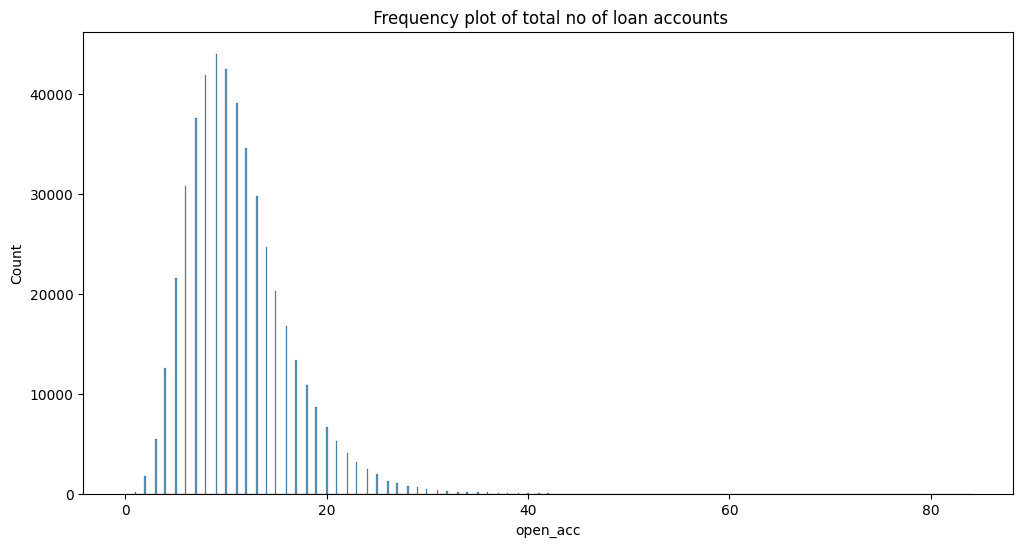

count    466070.000000
mean         11.187498
std           4.987403
min           0.000000
25%           8.000000
50%          10.000000
75%          14.000000
max          84.000000
Name: open_acc, dtype: float64
Median 10.0


In [204]:
plt.figure(figsize=(12,6))
sns.histplot(df[m11])
plt.title(' Frequency plot of total no of loan accounts')
plt.show()

print(df[m11].describe())
print(f"Median {df[m11].median()}")

In [205]:
# Since the distribution is right skewded - imputing median 
df[[m11]] = df[[m11]].fillna(df[m11].median())
print(df[m11].isna().sum())

0


# Col - 12

In [206]:
m12 =  col_with_null_values[11]                 
missing_values(m12)

____________________________________________________
	Analysing column - pub_rec
____________________________________________________

5 sample values----

303456    0.0
379786    0.0
54363     0.0
317647    1.0
424741    1.0
Name: pub_rec, dtype: float64


'The column pub_rec has 29 missing values, it is 0.0062219 % of total values'

In [207]:
print("It means - Number of derogatory public records on the borrower's credit report.")

It means - Number of derogatory public records on the borrower's credit report.


### Imputing `pub_rec`
- Numeric count, only 29 missing (~0.00%).


In [208]:
# Here Missing values means - the person has 0 negative public records- imputing= 0

df[[m12]] = df[[m12]].fillna(0)
print(df[m12].isna().sum())

0


# Col -  13

In [209]:
m13 =  col_with_null_values[12]                    # missing col 1 - m1
missing_values(m13)

____________________________________________________
	Analysing column - revol_util
____________________________________________________

5 sample values----

303456    69.0
379786    40.1
54363     40.1
317647    32.1
424741    82.1
Name: revol_util, dtype: float64


'The column revol_util has 339 missing values, it is 0.072731 % of total values'

In [210]:
print(df.loc[df[m13].isna(),:].head(15).to_string())

            id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  installment grade sub_grade                     emp_title emp_length home_ownership  annual_inc verification_status issue_d  loan_status pymnt_plan             purpose                              title zip_code addr_state    dti  delinq_2yrs earliest_cr_line  inq_last_6mths  mths_since_last_delinq  mths_since_last_record  open_acc  pub_rec  revol_bal  revol_util  total_acc initial_list_status  out_prncp  out_prncp_inv   total_pymnt  total_pymnt_inv  total_rec_prncp  total_rec_int  total_rec_late_fee  recoveries  collection_recovery_fee last_pymnt_d  last_pymnt_amnt next_pymnt_d last_credit_pull_d  collections_12_mths_ex_med  mths_since_last_major_derog  policy_code application_type  acc_now_delinq  tot_coll_amt  tot_cur_bal  total_rev_hi_lim
3577   1016416    1244120       8000         8000       8000.00000   36 months     19.42       294.95     E        E3        Medline Industries Inc    3 year

In [211]:
# So we found the revolving balance of the corresponding customers whose revolving utilization has missing values is zero 

# Let us let us check that for all customers do we have a revolving balance as

# To check we use only those values of the revolving balance where the revolving utilization is zero
df.loc[df[m13].isna(),['revol_bal']].value_counts()

revol_bal
0            273
41345          2
63283          1
39077          1
40000          1
            ... 
22258          1
26167          1
30207          1
31216          1
290291         1
Name: count, Length: 66, dtype: int64

In [212]:
# So we are now building those 273 customers with revolving balance as zero with a value zero in their revolving utilization
df.loc[ (df[m13].isna()) & (df['revol_bal'] == 0), m13] = 0

In [213]:
missing_values(m13)

____________________________________________________
	Analysing column - revol_util
____________________________________________________

5 sample values----

303456    69.0
379786    40.1
54363     40.1
317647    32.1
424741    82.1
Name: revol_util, dtype: float64


'The column revol_util has 66 missing values, it is 0.01416 % of total values'

In [214]:
print(df.loc[df[m13].isna(),:].head(15).to_string())
# So we have given two things first revolving balance 2nd revolving utilization and the 3rd more thing that is revolving account credit limit So 
# for those we don't have the revolving utilization we can compute it mathematically from the base limit of credit limit 

             id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  installment grade sub_grade                              emp_title emp_length home_ownership  annual_inc verification_status issue_d                                         loan_status pymnt_plan             purpose                                  title zip_code addr_state    dti  delinq_2yrs earliest_cr_line  inq_last_6mths  mths_since_last_delinq  mths_since_last_record  open_acc  pub_rec  revol_bal  revol_util  total_acc initial_list_status  out_prncp  out_prncp_inv   total_pymnt  total_pymnt_inv  total_rec_prncp  total_rec_int  total_rec_late_fee  recoveries  collection_recovery_fee last_pymnt_d  last_pymnt_amnt next_pymnt_d last_credit_pull_d  collections_12_mths_ex_med  mths_since_last_major_derog  policy_code application_type  acc_now_delinq  tot_coll_amt  tot_cur_bal  total_rev_hi_lim
37609    377376     401484       5000         5000      4440.371299   36 months     16.95       178.14  

In [215]:
print(df.loc[df[m13].isna(),['revol_bal',m13,'total_rev_hi_lim']].head(15).to_string())

        revol_bal  revol_util  total_rev_hi_lim
37609       49238         NaN               NaN
41175      290291         NaN               NaN
49606        1545         NaN            1500.0
52145        2028         NaN            2500.0
78172       15304         NaN           50000.0
79428        1960         NaN            1800.0
91962          58         NaN            9800.0
97987        1104         NaN            1204.0
98388        5330         NaN            5400.0
99411       42546         NaN           43000.0
106568      63283         NaN           65000.0
107952     127137         NaN          296150.0
114622       2937         NaN            5000.0
123695      67834         NaN           85000.0
128544      21400         NaN           21000.0


In [216]:
# So we are feeling only those values for which total revolving credit limit is given
print( df.loc[ (df[m13].isna())  & (df['total_rev_hi_lim'].notna()) , ['revol_bal',m13,'total_rev_hi_lim']].head(15).to_string())

        revol_bal  revol_util  total_rev_hi_lim
49606        1545         NaN            1500.0
52145        2028         NaN            2500.0
78172       15304         NaN           50000.0
79428        1960         NaN            1800.0
91962          58         NaN            9800.0
97987        1104         NaN            1204.0
98388        5330         NaN            5400.0
99411       42546         NaN           43000.0
106568      63283         NaN           65000.0
107952     127137         NaN          296150.0
114622       2937         NaN            5000.0
123695      67834         NaN           85000.0
128544      21400         NaN           21000.0
128633     113589         NaN          116000.0
143781     145450         NaN          150000.0


In [217]:
revol_bal = df.loc[ (df[m13].isna())  & (df['total_rev_hi_lim'].notna()) , 'revol_bal']
revol_limit = df.loc[ (df[m13].isna())  & (df['total_rev_hi_lim'].notna()) ,'total_rev_hi_lim' ]

df.loc[ (df[m13].isna())  & (df['total_rev_hi_lim'].notna()) , m13] = revol_bal  *100 / revol_limit

In [218]:
missing_values(m13)

____________________________________________________
	Analysing column - revol_util
____________________________________________________

5 sample values----

303456    69.0
379786    40.1
54363     40.1
317647    32.1
424741    82.1
Name: revol_util, dtype: float64


'The column revol_util has 6 missing values, it is 0.0012873 % of total values'

In [219]:
# So we are just remaining with six missing values and we are dropping 
# it because we don't have the revolving credit limit as well as the utilization We only have the balance
idx = df[df[m13].isna()].index
df = df.drop(index= idx)

# Column 14

In [220]:
m14 = col_with_null_values[13]
missing_values(m14)

____________________________________________________
	Analysing column - total_acc
____________________________________________________

5 sample values----

454156    48.0
15219     13.0
138078    27.0
335394    23.0
246880    17.0
Name: total_acc, dtype: float64


'The column total_acc has 29 missing values, it is 0.0062219 % of total values'

In [221]:
print(df.head().to_string())

        id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  installment grade sub_grade                 emp_title emp_length home_ownership  annual_inc verification_status issue_d  loan_status pymnt_plan         purpose                 title zip_code addr_state    dti  delinq_2yrs earliest_cr_line  inq_last_6mths  mths_since_last_delinq  mths_since_last_record  open_acc  pub_rec  revol_bal  revol_util  total_acc initial_list_status  out_prncp  out_prncp_inv   total_pymnt  total_pymnt_inv  total_rec_prncp  total_rec_int  total_rec_late_fee  recoveries  collection_recovery_fee last_pymnt_d  last_pymnt_amnt next_pymnt_d last_credit_pull_d  collections_12_mths_ex_med  mths_since_last_major_derog  policy_code application_type  acc_now_delinq  tot_coll_amt  tot_cur_bal  total_rev_hi_lim
0  1077501    1296599       5000         5000           4975.0   36 months     10.65       162.87     B        B2                   UNKNOWN  10+ years           RENT     24000.0     

In [222]:
df[['open_acc',m14]].sample(10)

,open_acc,total_acc
38353,10.0,19.0
123330,6.0,11.0
224155,12.0,17.0
213027,5.0,21.0
161041,13.0,49.0
306565,7.0,15.0
175567,13.0,36.0
30494,12.0,35.0
183766,13.0,21.0
135565,8.0,26.0


In [223]:
# Since we have missing values in the total credit account column So our logic is that is to fill it with current open accounts

# Before that we are going to check whether is it possible for a customer in a lending bank to have total account equals to the total open account
# which means that the person has opened the account recently and the bank has no info about its past accounts

df.loc[(df[m14].notna()) & (df[m14] ==  df['open_acc']), ['open_acc',m14]]
# It is possible

,open_acc,total_acc
7,4.0,4.0
13,11.0,11.0
24,7.0,7.0
34,6.0,6.0
53,11.0,11.0
...,...,...
465738,6.0,6.0
465831,8.0,8.0
465835,7.0,7.0
465914,5.0,5.0


In [224]:
df.loc[df[m14].isna(), m14]  =  df.loc[(df[m14].isna()) , 'open_acc']

# Column 15

In [225]:
m15 = col_with_null_values[14]
missing_values(m15)

____________________________________________________
	Analysing column - last_pymnt_d
____________________________________________________

5 sample values----

454156    Jan-16
15219     Sep-12
138078    Dec-15
335394    Dec-15
246880    Dec-15
Name: last_pymnt_d, dtype: object


'The column last_pymnt_d has 376 missing values, it is 0.080671 % of total values'

In [226]:
print(df.head().to_string())

        id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  installment grade sub_grade                 emp_title emp_length home_ownership  annual_inc verification_status issue_d  loan_status pymnt_plan         purpose                 title zip_code addr_state    dti  delinq_2yrs earliest_cr_line  inq_last_6mths  mths_since_last_delinq  mths_since_last_record  open_acc  pub_rec  revol_bal  revol_util  total_acc initial_list_status  out_prncp  out_prncp_inv   total_pymnt  total_pymnt_inv  total_rec_prncp  total_rec_int  total_rec_late_fee  recoveries  collection_recovery_fee last_pymnt_d  last_pymnt_amnt next_pymnt_d last_credit_pull_d  collections_12_mths_ex_med  mths_since_last_major_derog  policy_code application_type  acc_now_delinq  tot_coll_amt  tot_cur_bal  total_rev_hi_lim
0  1077501    1296599       5000         5000           4975.0   36 months     10.65       162.87     B        B2                   UNKNOWN  10+ years           RENT     24000.0     

In [227]:
col_with_null_values

['emp_title',
 'emp_length',
 'annual_inc',
 'desc',
 'title',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_util',
 'total_acc',
 'last_pymnt_d',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'total_rev_hi_lim']

In [228]:
df[['issue_d',m15,'next_pymnt_d']][df.notna()].head()

,issue_d,last_pymnt_d,next_pymnt_d
0,Dec-11,Jan-15,NaN
1,Dec-11,Apr-13,NaN
2,Dec-11,Jun-14,NaN
3,Dec-11,Jan-15,NaN
4,Dec-11,Jan-16,Feb-16


In [229]:
df.loc[(df[m15].isna()) & (df['next_pymnt_d'].notna()),[m15,'next_pymnt_d']]

,last_pymnt_d,next_pymnt_d
40122,NaN,Feb-11
40481,NaN,Oct-10
40498,NaN,Oct-10
40753,NaN,Jun-10
40769,NaN,Jun-10
40785,NaN,Jun-10
40848,NaN,May-10
40914,NaN,Apr-10
40927,NaN,Apr-10
41145,NaN,Nov-09


In [230]:
# So we just found that there are around A 10 to 15 columns where the last payment date is missing 
# We are imputing with the one month previous date for next payment date

df.loc[(df[m15].isna()) & (df['next_pymnt_d'].notna()),m15]  = ['Jan-11','Sep-10','Sep-10','Dec-09','Dec-09','Dec-09','Apr-09','Mar-09','Mar-09','Oct-09','Nov-08','Dec-08']

In [233]:
idx = df.loc[(df[m15].isna()),m15].index
df = df.drop(index = idx)

# Column 16

In [234]:
m16 = col_with_null_values[15]
missing_values(m16)

____________________________________________________
	Analysing column - next_pymnt_d
____________________________________________________

5 sample values----

253569    Feb-16
66450        NaN
223516       NaN
346569    Feb-16
22187        NaN
Name: next_pymnt_d, dtype: object


'The column next_pymnt_d has 226733 missing values, it is 48.683 % of total values'

In [241]:
df.loc[df[m16].isna(),['loan_status']].value_counts()

loan_status
Fully Paid     184650
Charged Off     42083
Name: count, dtype: int64

In [ ]:
# The 'next_pymnt_d' column is left as NaN for loans with status 'Fully Paid' or 'Charged Off',
# because these loans have no future scheduled payments. The missingness is structural (not an error),
# so imputing a date would be misleading. Instead, we retain NaN and optionally add a flag column
# to indicate "no next payment due".

# Column 17

In [242]:
m17 = col_with_null_values[16]
missing_values(m17)

____________________________________________________
	Analysing column - last_credit_pull_d
____________________________________________________

5 sample values----

253569    Jan-16
66450     Apr-15
223516    Jun-13
346569    Jan-16
22187     Oct-13
Name: last_credit_pull_d, dtype: object


'The column last_credit_pull_d has 42 missing values, it is 0.0090181 % of total values'

In [246]:
# The last credit poll date is a official information that is given by bank So
#  if it is not given it may be the bank has either not check credit history or it forget so where are you deleting it
idx = df[df[m17].isna()].index
df = df.drop(index= idx)

# Column 18 

In [248]:
m18 = col_with_null_values[17]
missing_values(m18)

____________________________________________________
	Analysing column - collections_12_mths_ex_med
____________________________________________________

5 sample values----

341346    0.0
316074    0.0
188811    0.0
63604     0.0
2060      0.0
Name: collections_12_mths_ex_med, dtype: float64


'The column collections_12_mths_ex_med has 143 missing values, it is 0.030707 % of total values'

In [250]:
df.loc[df[m18].isna(), ['loan_status', m18]]
df.loc[df[m18].isna(), ['loan_status']].value_counts()

loan_status                                        
Does not meet the credit policy. Status:Fully Paid     65
Fully Paid                                             50
Does not meet the credit policy. Status:Charged Off    22
Charged Off                                             6
Name: count, dtype: int64

In [253]:
# So on checking the loan status for those with missing values in their 'collection 12 month excluding medical' 
# we found that all those missing values are for those whose loan was already paid Or  they are defaulter

df.loc[df[m18].isna(),  m18] = 0

# Column 19

In [255]:
m19 = col_with_null_values[18]
missing_values(m19)

____________________________________________________
	Analysing column - mths_since_last_major_derog
____________________________________________________

5 sample values----

341346   NaN
316074   NaN
188811   NaN
63604    NaN
2060     NaN
Name: mths_since_last_major_derog, dtype: float64


'The column mths_since_last_major_derog has 366803 missing values, it is 78.766 % of total values'

In [256]:
df[19] = df[m19].fillna(0)

# Column 20 

In [257]:
m20 = col_with_null_values[19]
missing_values(m20)

____________________________________________________
	Analysing column - acc_now_delinq
____________________________________________________

5 sample values----

341346    0.0
316074    0.0
188811    0.0
63604     0.0
2060      0.0
Name: acc_now_delinq, dtype: float64


'The column acc_now_delinq has 28 missing values, it is 0.0060126 % of total values'

In [258]:
df[m20] = df[m20].fillna(0)

# column 21

In [259]:
m21 = col_with_null_values[20]
missing_values(m21)

____________________________________________________
	Analysing column - tot_coll_amt
____________________________________________________

5 sample values----

341346    0.0
316074    0.0
188811    0.0
63604     0.0
2060      NaN
Name: tot_coll_amt, dtype: float64


'The column tot_coll_amt has 70085 missing values, it is 15.05 % of total values'

In [261]:
df.loc[df[m21].isna(), ['loan_status']].value_counts()

loan_status                                        
Fully Paid                                             53627
Charged Off                                             9897
Current                                                 3584
Does not meet the credit policy. Status:Fully Paid      1984
Does not meet the credit policy. Status:Charged Off      761
Late (31-120 days)                                       121
In Grace Period                                           66
Late (16-30 days)                                         27
Default                                                   18
Name: count, dtype: int64

In [266]:
df.to_csv("Cleaned_lending_club_2007_2014.csv")